# Minimum-cost flow · repair a residue network

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from parvaneh import (reliability_unwrap, pixel_reliability,
                      network_flow_unwrap, phase_residues, rmse_aligned)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, ORANGE, RED = '#2463a6', '#d78b26', '#b83d52'
def wrap(a):
    return (np.asarray(a) + np.pi) % (2*np.pi) - np.pi
def gradients(a):
    return wrap(np.diff(a, axis=1)), wrap(np.diff(a, axis=0))
def curl(gx, gy):
    return gx[:-1] + gy[:, 1:] - gx[1:] - gy[:, :-1]
def table(headers, rows):
    display(Markdown('| ' + ' | '.join(headers) + ' |\n|' +
        '|'.join(['---'] * len(headers)) + '|\n' +
        '\n'.join('| ' + ' | '.join(map(str, row)) + ' |' for row in rows)))

## 1 · Four angles, two incompatible paths

Label the corners $A,B,C,D$ clockwise. Their measured phases, **in units of
$\pi$**, are $0,0.6,-0.8,-0.2$. These are actual pixel measurements;
we do not invent independent edge errors.

For a directed edge $a\to b$, compute

$$g_{ab}=W(w_b-w_a),\qquad W(t)=((t+\pi)\bmod 2\pi)-\pi.$$

Walk clockwise. The four steps are $0.6\pi,0.6\pi,0.6\pi,0.2\pi$.
Their sum is $2\pi$, giving residue $r=1$. In particular, from $A$ to $C$:

$$A\to B\to C: 1.2\pi,\qquad A\to D\to C:-0.8\pi.$$

Both paths look locally plausible, but their answers differ by one whole turn.
An ordinary scalar surface cannot have both sets of differences simultaneously.

| Clockwise edge | Raw difference / π | Wrapped step / π |
|---|---|---|
| A → B | 0.6 | 0.6 |
| B → C | -1.4 | 0.6 |
| C → D | 0.6 | 0.6 |
| D → A | 0.2 | 0.2 |

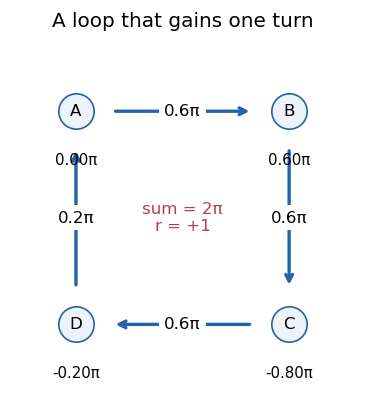

In [2]:
w = np.pi * np.array([[0.0, 0.6], [-0.2, -0.8]])
gx, gy = gradients(w)
steps = np.array([gx[0,0], gy[0,1], -gx[1,0], -gy[0,0]])
assert np.allclose(steps / np.pi, [.6, .6, .6, .2])
assert phase_residues(w)[0,0] == 1
table(['Clockwise edge', 'Raw difference / π', 'Wrapped step / π'],
      [(name, f'{raw:.1f}', f'{step:.1f}') for name, raw, step in
       zip(['A → B','B → C','C → D','D → A'], [.6,-1.4,.6,.2], steps/np.pi)])

xy = np.array([[0,1], [1,1], [0,0], [1,0]])  # flattened array order A,B,D,C
names = ['A','B','D','C']
def square(ax, values, title, edges=None, labels=None):
    edges = [(0,1),(1,3),(3,2),(2,0)] if edges is None else edges
    for i,(a,b) in enumerate(edges):
        p,q = xy[a],xy[b]
        ax.annotate('', xy=q*.83+p*.17, xytext=p*.83+q*.17,
                    arrowprops=dict(arrowstyle='->', color=BLUE, lw=2))
        if labels is not None:
            mid=(p+q)/2
            ax.text(*mid, labels[i], ha='center', va='center',
                    bbox=dict(facecolor='white', edgecolor='none', pad=3))
    for i,p in enumerate(xy):
        ax.scatter(*p, s=450, color='#edf3fa', edgecolor=BLUE, zorder=3)
        ax.text(p[0],p[1],names[i],ha='center',va='center',zorder=4)
        ax.text(p[0],p[1]-.25,f'{values.ravel()[i]/np.pi:.2f}π',ha='center',fontsize=9)
    ax.set(xlim=(-.3,1.3),ylim=(-.35,1.35),aspect='equal',title=title)
    ax.axis('off')
fig,ax=plt.subplots(figsize=(5,4))
square(ax,w,'A loop that gains one turn',labels=['0.6π','0.6π','0.6π','0.2π'])
ax.text(.5,.5,'sum = 2π\nr = +1',ha='center',va='center',color=RED)
plt.show()

## 4 · Flow: pay for integer corrections instead

Keep all edges, but allow a corrected step $h_e=g_e+2\pi k_e$ with integer
$k_e$. Let $s_{Ce}=+1$ when cell $C$ traverses an edge in its stored direction
and $-1$ otherwise. Closure requires

$$\sum_{e\in C}s_{Ce}h_e=0
\quad\Longleftrightarrow\quad
\sum_{e\in C}s_{Ce}k_e=-r_C.$$

For our clockwise loop $r=+1$. Subtracting one turn from **any one** of its
four clockwise steps restores closure. There are four choices. With positive
prices $c_e$, the linear objective is

$$\min_{k\in\mathbb Z^E}\sum_e c_e|k_e|.$$

On this single cell, one correction on the cheapest edge is optimal: a feasible
solution needs at least one turn, and additional positive-cost turns cannot help.
This is a tiny optimization problem we can enumerate before calling a solver.

| Edge corrected | Corrected clockwise steps / π | Cost |
|---|---|---|
| A→B | -1.4, 0.6, 0.6, 0.2 | 4.0 |
| B→C | 0.6, -1.4, 0.6, 0.2 | 1.0 |
| C→D | 0.6, 0.6, -1.4, 0.2 | 3.0 |
| D→A | 0.6, 0.6, 0.6, -1.8 | 2.0 |

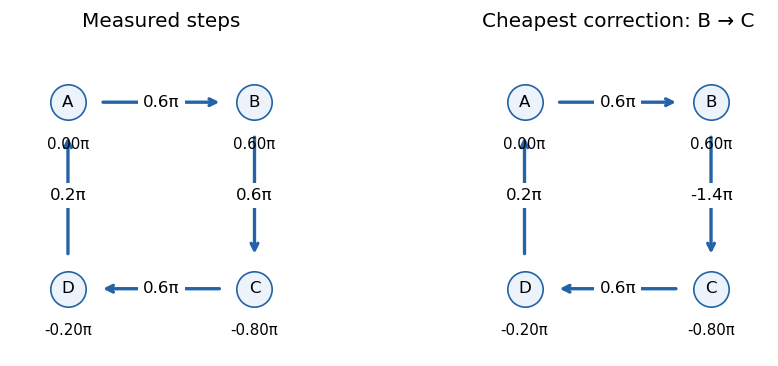

In [3]:
prices=np.array([4.,1.,3.,2.])  # illustrative clockwise edge prices
options=[]
for e in range(4):
    k=np.zeros(4,dtype=int); k[e]=-1
    corrected=steps+2*np.pi*k
    assert np.isclose(corrected.sum(),0)
    options.append([['A→B','B→C','C→D','D→A'][e],
                    ', '.join(f'{v:.1f}' for v in corrected/np.pi),prices[e]])
table(['Edge corrected','Corrected clockwise steps / π','Cost'],options)
best=int(np.argmin(prices))
fig,axes=plt.subplots(1,2,figsize=(9,3.5))
square(axes[0],w,'Measured steps',labels=[f'{v:.1f}π' for v in steps/np.pi])
fixed=steps.copy(); fixed[best]-=2*np.pi
square(axes[1],w,'Cheapest correction: B → C',labels=[f'{v:.1f}π' for v in fixed/np.pi])
plt.show()

## 5 · Why cells become network nodes

Two adjacent cells traverse their shared pixel edge in opposite directions.
Adding one turn to that edge changes their charges oppositely: a correction
can therefore be represented as flow between the **cell centers**. This is the
dual network. A route through several cells transfers a unit of charge from
one end of the route to the other, leaving intermediate cells balanced.

Boundary edges connect to an extra exterior node, often called ground. A net
charge can be balanced through this node; opposite residues need not always be
paired inside the image. “Ground” here is a network node, not a known phase value.

The next diagram is the geometry, not a computed optimal route. Dashed orange
links connect cell centers across pixel edges. The purple link reaches outside.

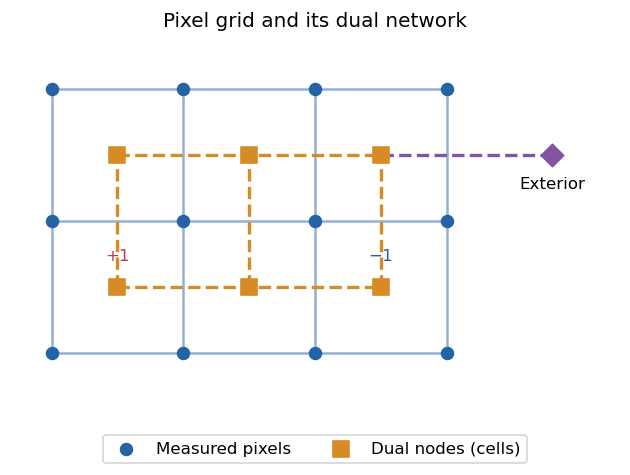

In [4]:
fig,ax=plt.subplots(figsize=(7,4))
for y0 in range(3): ax.plot([0,3],[y0,y0],color=BLUE,alpha=.5)
for x0 in range(4): ax.plot([x0,x0],[0,2],color=BLUE,alpha=.5)
xx,yy=np.meshgrid(np.arange(4),np.arange(3))
ax.scatter(xx,yy,color=BLUE,s=50,label='Measured pixels',zorder=3)
for y0 in [.5,1.5]:
    ax.plot([.5,2.5],[y0,y0],'--',color=ORANGE,lw=2)
for x0 in [.5,1.5,2.5]:
    ax.plot([x0,x0],[.5,1.5],'--',color=ORANGE,lw=2)
cx,cy=np.meshgrid([.5,1.5,2.5],[.5,1.5])
ax.scatter(cx,cy,marker='s',s=90,color=ORANGE,label='Dual nodes (cells)',zorder=4)
ax.plot([2.5,3.8],[1.5,1.5],'--',color='#8054a1',lw=2)
ax.scatter([3.8],[1.5],marker='D',s=90,color='#8054a1')
ax.text(3.8,1.25,'Exterior',ha='center')
ax.text(.5,.7,'+1',ha='center',color=RED)
ax.text(2.5,.7,'−1',ha='center',color=BLUE)
ax.set(aspect='equal',xlim=(-.3,4.3),ylim=(-.35,2.4),title='Pixel grid and its dual network')
ax.legend(loc='lower center',bbox_to_anchor=(.5,-.2),ncol=2); ax.axis('off')
plt.show()

### How the flow solve proceeds

1. Compute each cell's integer residue and the exterior balancing charge.
2. Create arcs across pixel edges, with prices for integer corrections.
3. Find a cheapest residual-network path from available supply to demand.
4. Send flow along it; reverse arcs allow earlier routing decisions to be undone.
5. Repeat until all charges balance, then integrate the corrected pixel steps.

For the 2-D linear-cost network with integral charges, network optimization has
an integral optimum. That is an optimum for the stated correction cost, not a
guarantee of recovering the physical truth. Tied costs can produce different
equally optimal surfaces. Masks need additional care: removing cell constraints
does not automatically enforce closure around a hole.

`network_flow_unwrap` takes **pixel** confidence rather than arbitrary edge
prices. It clips confidence to [0,1], scales by 1000, rounds to integer costs,
and uses the minimum endpoint cost. Positive confidence is given a minimum cost
of 1; zero confidence excludes pixels. Thus our four independent illustrative
prices above are a teaching model, not an API argument.

In [5]:
flow_small,flow_info=network_flow_unwrap(w,return_info=True)
fx,fy=gradients(w)
kx=np.rint((np.diff(flow_small,axis=1)-fx)/(2*np.pi)).astype(int)
ky=np.rint((np.diff(flow_small,axis=0)-fy)/(2*np.pi)).astype(int)
assert np.allclose(curl(fx+2*np.pi*kx,fy+2*np.pi*ky),0)
assert np.allclose(wrap(flow_small-w),0)
assert flow_info.total_cost==1000  # unit confidence, exactly one turn
print(flow_info)
print('Right-edge corrections (turns):\n',kx)
print('Down-edge corrections (turns):\n',ky)

NetworkFlowInfo(backend='python', cost='linear', pixels=4, nodes=2, edges=4, residues=1, augmentations=1, components=1, max_jump=1, ground_imbalance=1, total_cost=1000)
Right-edge corrections (turns):
 [[0]
 [0]]
Down-edge corrections (turns):
 [[1 0]]
